In [ ]:
!pip -q install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip -q install trl datasets accelerate peft bitsandbytes transformers sentencepiece evaluate matplotlib pandas
!pip -q install lm-eval

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Как обучаются LLM?

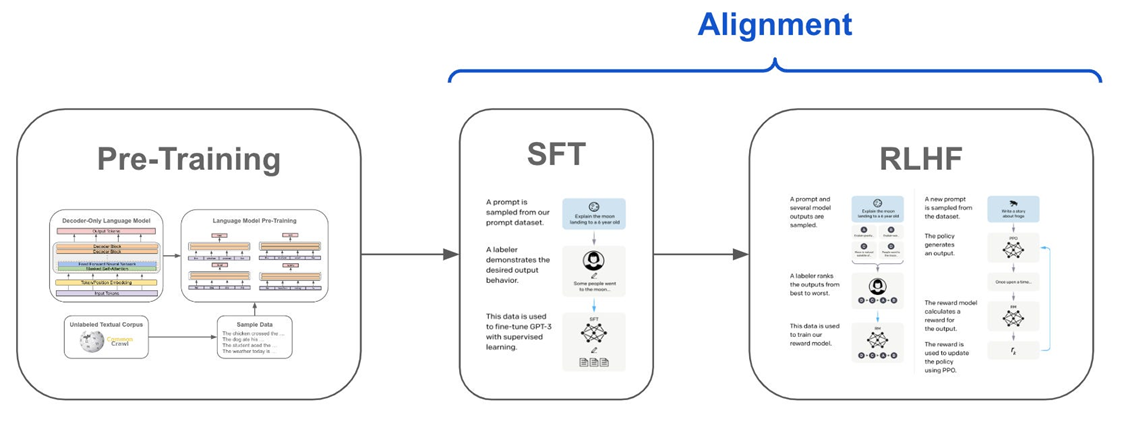

### Данные

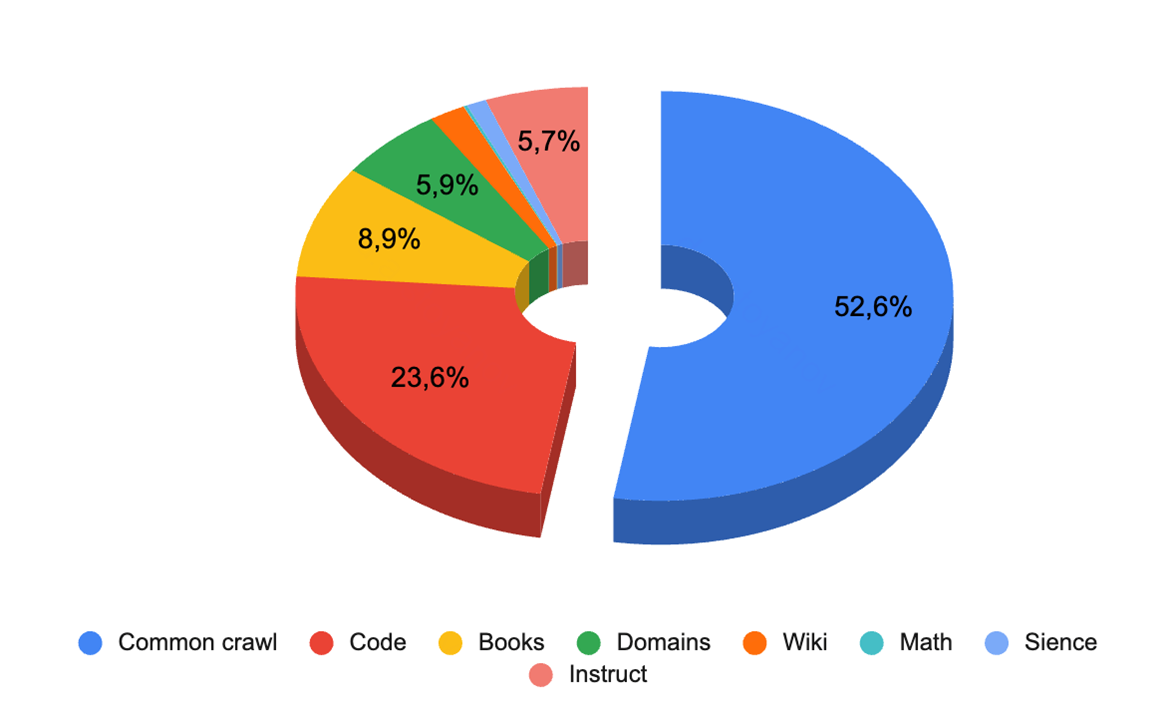

### Предобработка

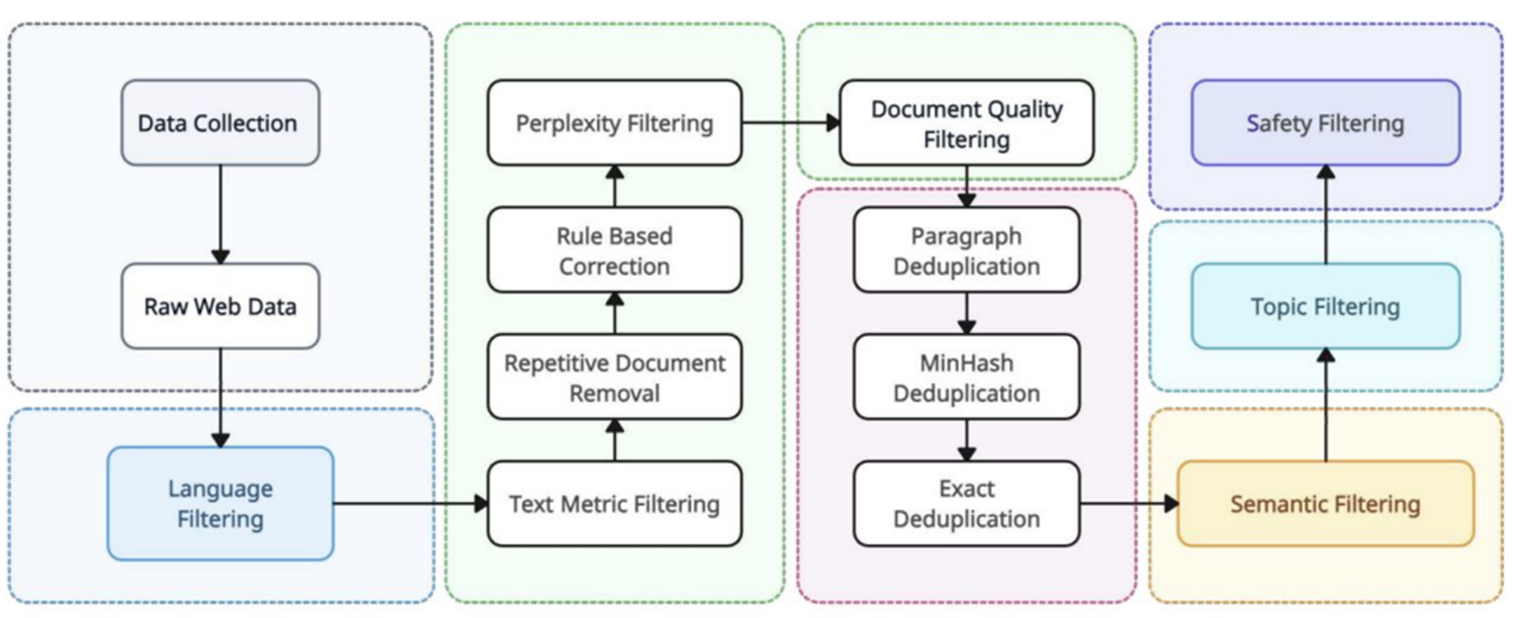

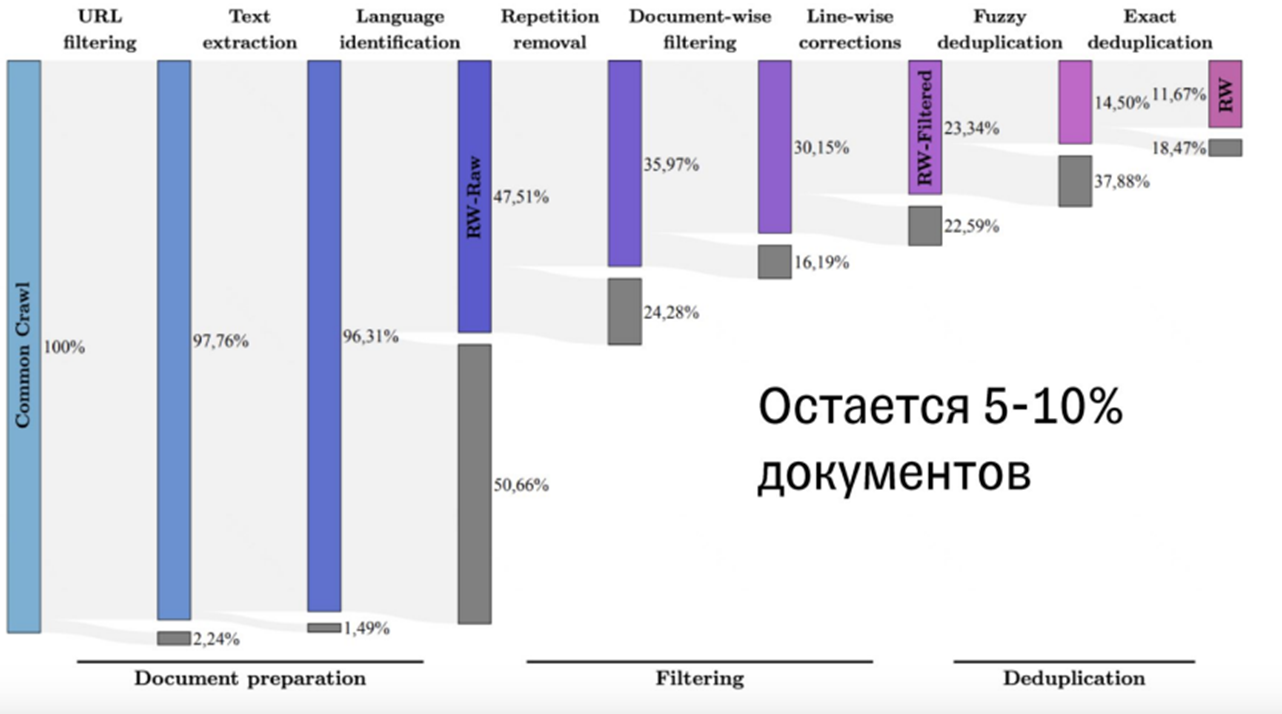

### Некоторые техники Pretrain'а

- Настройка пропорций языков в корпусе; перевзвешивание недопредставленных языков
- Data Mixture: комбинирование различных типов данных (web, книги, код, диалоги, SFT). Часто используют взвешивание по этапам обучения.
- Curriculum learning:
  - Начальный этап — объёмные, но простые тексты.
  - Переход к узкоспециальным и сложным (код, математика).
  - Финальная фаза — данные SFT и preference data


## Адаптация под домен

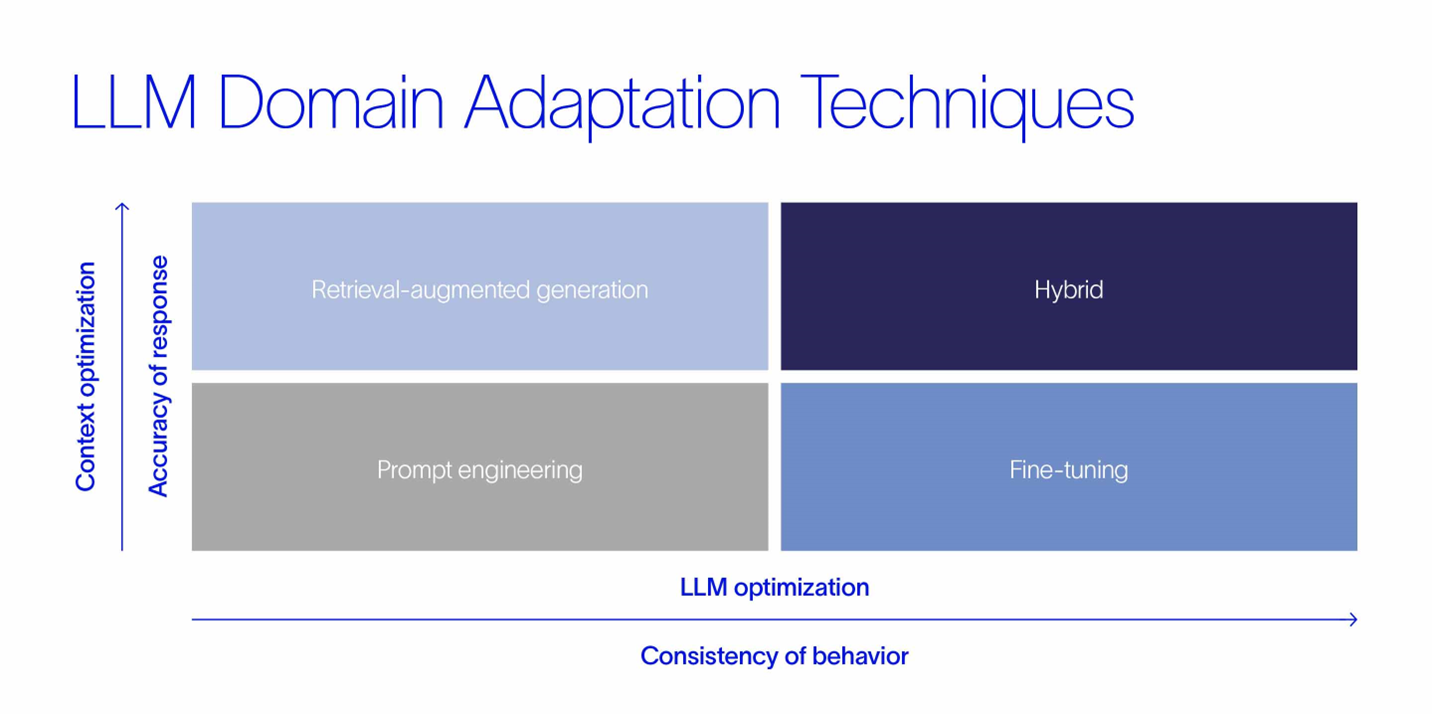

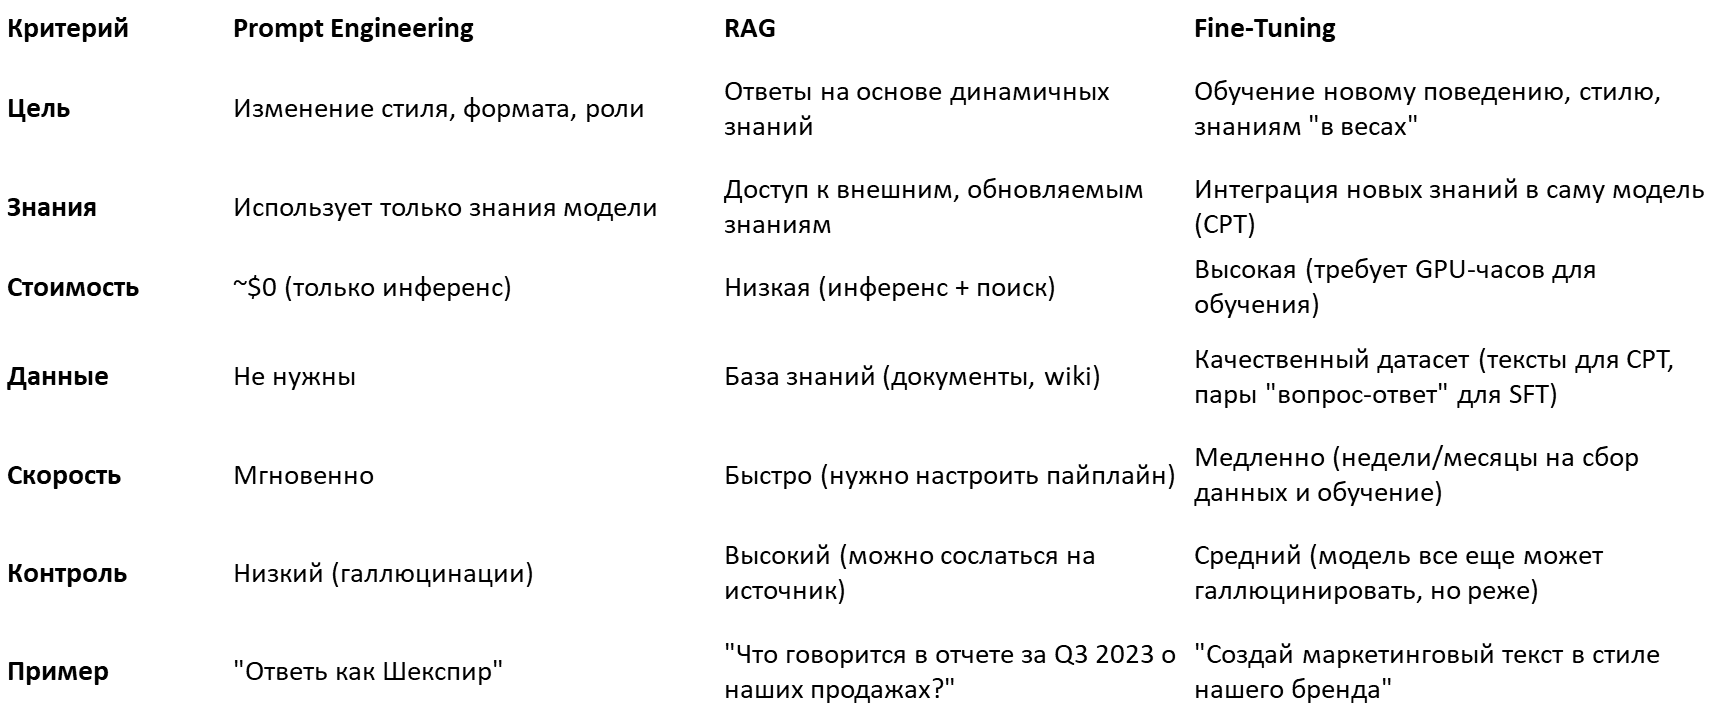

### CPT vs SFT

- **Continual Pre-Training (CPT)** — это процесс дополнительного обучения уже предварительно обученной языковой модели на новых доменно-специфических данных с использованием той же задачи языкового моделирования.
- **Supervised Fine-Tuning (SFT)** — это процесс настройки предварительно обученной модели на конкретной задаче с использованием размеченных пар "вход-выход".


CPT – когда уместен:
- Адаптация под специфическую лексику, отсутствующую в исходных данных обучения
- Интеграция новых фактических знаний
- Адаптация к новым языкам
- Хотим удлинить контекст

SFT – не добавляет новых знаний, менее требователен к ресурсам


Возможны разные миксы с PEFT:
- CPT, SFT + PEFT
- CPT + PEFT, SFT + PEFT, одинаковые адаптеры
- CPT + доменные PEFT, SFT + task-PEFT


## Пример SFT

In [ ]:
import os, gc, math, time, json, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from transformers import TrainingArguments, EarlyStoppingCallback


from unsloth.chat_templates import get_chat_template
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig


/tmp/ipykernel_4905/2091256513.py:11: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth.chat_templates import get_chat_template


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


### Утилиты  и настройки

In [ ]:
import warnings

warnings.simplefilter('ignore')

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
def cuda_mem(label=""):
    if not torch.cuda.is_available():
        print("CUDA not available")
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    max_alloc = torch.cuda.max_memory_allocated() / 1024**2
    print(f"[VRAM] {label} allocated={allocated:.0f} MB | reserved={reserved:.0f} MB | max_alloc={max_alloc:.0f} MB")

In [ ]:
def reset_cuda_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

In [ ]:
MODEL_NAME = "unsloth/Qwen3-0.6B"
DATASET_NAME = "Vikhrmodels/GrandMaster-PRO-MAX"

SEED = 42
MAX_SEQ_LENGTH = 2048
PACKING = True

# корзинка промптов до/после
prompts_for_test = [
    'Как вкусно приготовить индейку на гриле?',
    'Как распознать приближающийся инсульт?',
    'Сформулируй основные каноны архитектуры древних цивилизаций',
    'Облагать ли страховыми взносами суммы прощенного долга по займу от организации где работает застрахованный?',
    'Расскажи мне про Курчатова'
]

In [ ]:
set_seed(SEED)
cuda_mem("start")

[VRAM] start allocated=8 MB | reserved=22 MB | max_alloc=8 MB


### Загрузка модели (4-bit) + включение chat template (instruct-формат)

In [ ]:
reset_cuda_peak()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

cuda_mem("after model load (4bit)")

==((====))==  Unsloth 2026.3.4: Fast Qwen3 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[VRAM] after model load (4bit) allocated=592 MB | reserved=626 MB | max_alloc=608 MB


In [ ]:
tokenizer.chat_template

'{%- if tools %}\n    {{- \'<|im_start|>system\\n\' }}\n    {%- if messages[0].role == \'system\' %}\n        {{- messages[0].content + \'\\n\\n\' }}\n    {%- endif %}\n    {{- "# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>" }}\n    {%- for tool in tools %}\n        {{- "\\n" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- "\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\"name\\": <function-name>, \\"arguments\\": <args-json-object>}\\n</tool_call><|im_end|>\\n" }}\n{%- else %}\n    {%- if messages[0].role == \'system\' %}\n        {{- \'<|im_start|>system\\n\' + messages[0].content + \'<|im_end|>\\n\' }}\n    {%- endif %}\n{%- endif %}\n{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}\n{%- for forward_message 

### Быстрая генерация до обучения

In [ ]:
FastLanguageModel.for_inference(model)

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024, padding_idx=151669)
    (layers): ModuleList(
      (0): Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_lay

In [ ]:
def generate_chat(model, tokenizer, user_text, system_text="Ты — полезный русскоязычный ассистент.", max_new_tokens=220):
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return text


In [ ]:
model.device

device(type='cuda', index=0)

In [ ]:
for p in prompts_for_test:
  print(p)
  print(generate_chat(model, tokenizer, p)[:1500])
  print("="*250)

Как вкусно приготовить индейку на гриле?


--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, 

system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
<think>
Хорошо, пользователь спрашивает, как приготовить индейку на гриле. Нужно дать точные шаги, но также учесть, что индейка может быть сухой или кислорожной, и выбрать правильный метод. Сначала нужно определить, какой вид индейки использовать: сухая или кислорожная. Потом обсудить инструкцию по приготовлению. Важно упомянуть о том, что индейка готовится как в тёплой воде, но для кислорожной она лучше готовить в воде, а сухая — в молоке. Также важно указать, какие инструменты нужны, например, кухонная палочка, сковородка, тушателя. Завершить ответом, чтобы пользователь понимал, что есть варианты подготовки, и что
Как распознать приближающийся инсульт?
system
Ты — полезный русскоязычный ассистент.
user
Как распознать приближающийся инсульт?
assistant
<think>
Хорошо, пользователь спрашивает, как распознать приближающийся инсульт. Нужно дать ответ, который будет содержать точные методы

### Бенчмарк до обучения (LM Evaluation Harness)

In [ ]:
BASE_BENCH_DIR = "/content/bench_base"
os.makedirs(BASE_BENCH_DIR, exist_ok=True)

In [ ]:
# TruthfulQA (быстро)
!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 8 \
  --limit 50 \
  --output_path {BASE_BENCH_DIR}/truthfulqa_base.json

2026-03-12:10:23:27 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-03-12:10:23:37 INFO     [_cli.run:376] Selected Tasks: ['truthfulqa_mc2']
2026-03-12:10:23:37 INFO     [evaluator:211] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-03-12:10:23:37 INFO     [evaluator:236] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen3-0.6B', 'trust_remote_code': True}
2026-03-12:10:23:41 INFO     [models.huggingface:161] Using device 'cuda:0'
2026-03-12:10:23:43 INFO     [models.huggingface:423] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}
Loading weights: 100% 310/310 [00:04<00:00, 66.86it/s, Materializing param=model.norm.weight]
2026-03-12:10:23:50 INFO     [tasks:700] Selected tasks:
2026-03-12:10:23:50 INFO     [tasks:691] Task: truthfulqa_mc2 (truthfulqa

### Загрузка датасета

In [ ]:
ds = load_dataset(DATASET_NAME)
ds

DatasetDict({
    train: Dataset({
        features: ['source', 'conversation', 'prompt_tokens', 'answer_tokens', 'cluster', 'prompt_lang', 'answer_lang'],
        num_rows: 151822
    })
    test: Dataset({
        features: ['source', 'conversation', 'prompt_tokens', 'answer_tokens', 'cluster', 'prompt_lang', 'answer_lang'],
        num_rows: 3291
    })
})

In [ ]:
def to_messages(example):
    conversation = example.get("conversation", [])

    if not isinstance(conversation, list):
        conversation = [conversation]

    user = next(
        (
            msg.get("content", "")
            for msg in conversation
            if isinstance(msg, dict) and msg.get("role") == "user"
        ),
        ""
    )

    assistant = next(
        (
            msg.get("content", "")
            for msg in conversation
            if isinstance(msg, dict) and msg.get("role") == "assistant"
        ),
        ""
    )

    return [
        {"role": "system", "content": "Ты — полезный русскоязычный ассистент."},
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant},
    ]


In [ ]:
def format_text(example):
    messages = to_messages(example)
    # В SFT хотим обучать на полных диалогах, без generation prompt:
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text, "messages_norm": messages}

In [ ]:
raw = ds['train'].shuffle(seed=SEED).select(range(min(6000, len(ds['train']))))

raw2 = raw.map(format_text, remove_columns=raw.column_names)
raw2[0]["text"][:500]

'<|im_start|>system\nТы — полезный русскоязычный ассистент.<|im_end|>\n<|im_start|>user\nУ меня возникла небольшая заминка с геометрической задачей, и я надеюсь, ты сможешь помочь. Вот описание задачи:\n\nДаны два круга, один меньше другого. Меньший круг касается большего внутренним образом в одной точке. Через эту точку касания проведена общая касательная к этим кругам, которая образует с линией центров кругов угол в 30 градусов. Необходимо найти отношение радиусов этих кругов.\n\nМожешь ли ты помочь м'

In [ ]:
dataset = raw2.train_test_split(test_size=0.02, seed=SEED)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'messages_norm'],
        num_rows: 5880
    })
    test: Dataset({
        features: ['text', 'messages_norm'],
        num_rows: 120
    })
})

### Аудит данных

In [ ]:
def token_len(text):
    return len(tokenizer(text, add_special_tokens=False).input_ids)

In [ ]:
lens = [token_len(x) for x in dataset["train"]["text"][:2000]]
print("len stats:", pd.Series(lens).describe(percentiles=[0.5,0.9,0.95,0.99]).to_dict())

len stats: {'count': 2000.0, 'mean': 709.301, 'std': 318.2613038491547, 'min': 43.0, '50%': 712.0, '90%': 1093.0, '95%': 1236.1, '99%': 1557.01, 'max': 2244.0}


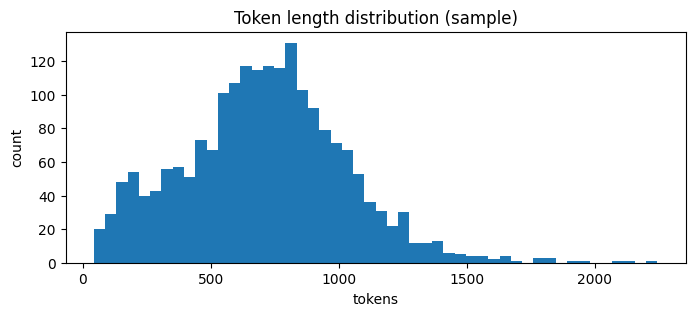

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(lens, bins=50)
plt.title("Token length distribution (sample)")
plt.xlabel("tokens"); plt.ylabel("count")
plt.show()

### LoRA

In [ ]:
n*n | [n*r] * [r*n] = [n*n]

lora_alpha/r=1

In [ ]:
def add_lora(model, r=16, lora_alpha=32, target="attn_mlp", dropout=0.0):
    if target == "attn":
        target_modules = ["q_proj","k_proj","v_proj","o_proj"]
    else:
        target_modules = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]

    model = FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=lora_alpha,
        lora_dropout=dropout,
        bias="none",
        target_modules=target_modules,
        use_gradient_checkpointing=True,  # VRAM vs speed trade-off
        random_state=SEED,
        use_rslora=False,
    )
    return model, target_modules

In [ ]:
def trainable_params_report(model):
    trainable = 0
    total = 0
    for p in model.parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
    return {"trainable": trainable, "total": total, "trainable_pct": 100*trainable/total}

In [ ]:
ablation_confs = [
    {"name":"attn_only_r8_a16",  "r":8,  "alpha":16, "target":"attn"},
    {"name":"attn_mlp_r16_a32",  "r":16, "alpha":32, "target":"attn"},
]

ablation_confs

[{'name': 'attn_only_r8_a16', 'r': 8, 'alpha': 16, 'target': 'attn'},
 {'name': 'attn_mlp_r16_a32', 'r': 16, 'alpha': 32, 'target': 'attn'}]

### Обучение SFT (TRL)

In [ ]:
def run_sft_one(conf, output_dir):
    global model, tokenizer

    # Перезагрузим базовую 4bit модель для чистоты эксперимента
    del model
    gc.collect()
    torch.cuda.empty_cache()
    reset_cuda_peak()

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = MODEL_NAME,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype = None,
        load_in_4bit = True,
    )

    print("before eos:", repr(tokenizer.eos_token), tokenizer.eos_token_id)
    print("before pad:", repr(tokenizer.pad_token), tokenizer.pad_token_id)

    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

    model.config.pad_token_id = tokenizer.pad_token_id
    if getattr(model, "generation_config", None) is not None:
        model.generation_config.pad_token_id = tokenizer.pad_token_id

    print("after eos:", repr(tokenizer.eos_token), tokenizer.eos_token_id)
    print("after pad:", repr(tokenizer.pad_token), tokenizer.pad_token_id)
    assert tokenizer.convert_tokens_to_ids(tokenizer.pad_token) == tokenizer.pad_token_id

    model, target_modules = add_lora(
        model,
        r=conf["r"],
        lora_alpha=conf["alpha"],
        target=conf["target"],
        dropout=0.0,
    )

    rep = trainable_params_report(model)
    print("Ablation:", conf)
    print("target_modules:", target_modules)
    print("trainable params:", rep)

    steps = 200

    args = SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        warmup_ratio=0.1,
        max_steps=steps,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=20,
        save_strategy="steps",
        save_steps=20,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        optim="paged_adamw_8bit",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        report_to="none",
        seed=SEED,
        dataset_text_field="text",
        max_length=MAX_SEQ_LENGTH,
        packing=PACKING,
    )

    trainer = SFTTrainer(
        model=model,
        processing_class=tokenizer,
        train_dataset=dataset["train"],
        eval_dataset=dataset["test"],
        args=args,
    )

    trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

    cuda_mem("before train")
    t0 = time.time()
    out = trainer.train()
    t1 = time.time()
    cuda_mem("after train")
    print("train time (min):", (t1 - t0) / 60)

    return trainer, out

In [ ]:
MAIN_CONF = ablation_confs[1]  # attn r16 alpha32
trainer, train_out = run_sft_one(MAIN_CONF, output_dir="sft_runs/main")

==((====))==  Unsloth 2026.3.4: Fast Qwen3 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
before eos: '<|im_end|>' 151645
before pad: '<|PAD_TOKEN|>' 151669
after eos: '<|im_end|>' 151645
after pad: '<|im_end|>' 151645


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.3.4 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Ablation: {'name': 'attn_mlp_r16_a32', 'r': 16, 'alpha': 32, 'target': 'attn'}
target_modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj']
trainable params: {'trainable': 4587520, 'total': 393019392, 'trainable_pct': 1.167250291812573}


...

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!
[VRAM] before train allocated=1238 MB | reserved=1270 MB | max_alloc=1239 MB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,070 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 600,637,440 (0.76% trained)


Step,Training Loss,Validation Loss
20,1.636752,1.567276
40,1.464277,1.495479
60,1.417862,1.475415
80,1.434553,1.463048
100,1.440562,1.454568
120,1.415430,1.445721
140,1.407053,1.437726
160,1.423696,1.433110
180,1.368618,1.429994
200,1.369413,1.428773


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


[VRAM] after train allocated=1248 MB | reserved=2816 MB | max_alloc=5722 MB
train time (min): 121.53604749838512


### Проверка после обучения на корзинке промптов

In [ ]:
FastLanguageModel.for_inference(trainer.model)

for p in prompts_for_test:
    print(p)
    ans = generate_chat(trainer.model, tokenizer, p, max_new_tokens=240)
    print(ans[:1800])
    print('='*250)

Как вкусно приготовить индейку на гриле?
system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
Для приготовления индейки на гриле, вы можете следовать этим шагам:

1. **Подготовка индейки**: Несколько упругих и тонких индей, которые легко подогреваются, чтобы уменьшить их жаропламентность.

2. **Подготовка гриль**: Заготовьте гриль с кухней, и стелите ее по углах или вдоль, чтобы она оставалась в той же температуре, как и индейка.

3. **Передготовка индейки**: Снимите индейку с своего места, разберитесь с ней, чтобы убрать мускульные остатки, и дайте ей немного времени для остывания, чтобы уменьшить жаропламентность.

4. **Варка индейки**: Варим индейку на гриле, пока не будет готова. Если вы хотите более жаркое вкус, возможно, стоит добавить немного горяч
Как распознать приближающийся инсульт?
system
Ты — полезный русскоязычный ассистент.
user
Как распознать приближающийся инсульт?
assistant
Приближение инсульта может быть симптоматическ

### Сохранение адаптеров

In [ ]:
ADAPTER_DIR = "/content/artifacts/adapter_only"
os.makedirs(ADAPTER_DIR, exist_ok=True)

trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("Saved adapter to:", ADAPTER_DIR)

Saved adapter to: /content/artifacts/adapter_only


### Проверка на бенчмарке

In [ ]:
SFT_BENCH_DIR = "/content/bench_sft"
os.makedirs(SFT_BENCH_DIR, exist_ok=True)

In [ ]:
!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},peft={ADAPTER_DIR},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 8 \
  --limit 50 \
  --output_path {SFT_BENCH_DIR}/truthfulqa_sft.json

2026-03-12:12:28:10 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-03-12:12:28:17 INFO     [_cli.run:376] Selected Tasks: ['truthfulqa_mc2']
2026-03-12:12:28:17 INFO     [evaluator:211] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-03-12:12:28:17 INFO     [evaluator:236] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen3-0.6B', 'peft': '/content/artifacts/adapter_only', 'trust_remote_code': True}
2026-03-12:12:28:21 INFO     [models.huggingface:161] Using device 'cuda:0'
2026-03-12:12:28:23 INFO     [models.huggingface:423] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}
Loading weights: 100% 310/310 [00:00<00:00, 687.50it/s, Materializing param=model.norm.weight]
2026-03-12:12:28:25 INFO     [models.huggingface:703] Model config indicates vocab_siz

In [ ]:
def read_lm_eval(path):
    with open(path, "r", encoding="utf-8") as f:
        j = json.load(f)
    results = j.get("results", {})
    return results

base_path = "/content/bench_base/truthfulqa_base_2026-03-12T10-24-35.584942.json"
sft_path  = "/content/bench_sft/truthfulqa_sft_2026-03-12T12-29-16.680799.json"

base_res = read_lm_eval(base_path)
sft_res = read_lm_eval(sft_path)

print("BASE:", base_res)
print("SFT:", sft_res)

# Обычно интересны ключи вроде "acc", "acc_norm", "mc2"
task = "truthfulqa_mc2"
if task in base_res and task in sft_res:
    print("\nDelta:", {k: sft_res[task].get(k) - base_res[task].get(k)
                     for k in sft_res[task].keys() if isinstance(sft_res[task].get(k), (int,float)) and k in base_res[task]})

BASE: {'truthfulqa_mc2': {'alias': 'truthfulqa_mc2', 'acc,none': 0.4368451776831864, 'acc_stderr,none': 0.05805210486117057}}
SFT: {'truthfulqa_mc2': {'alias': 'truthfulqa_mc2', 'acc,none': 0.4939760151152038, 'acc_stderr,none': 0.06157117154164829}}

Delta: {'acc,none': 0.057130837432017356, 'acc_stderr,none': 0.003519066680477717}


### Слияние адаптеров

In [ ]:
MERGED_DIR = "/content/artifacts/merged_16bit"
os.makedirs(MERGED_DIR, exist_ok=True)

trainer.model.save_pretrained_merged(MERGED_DIR, tokenizer, save_method="merged_16bit")
print("Saved merged 16-bit to:", MERGED_DIR)

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:10<00:00, 10.15s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:14<00:00, 14.11s/it]


Unsloth: Merge process complete. Saved to `/content/artifacts/merged_16bit`
Saved merged 16-bit to: /content/artifacts/merged_16bit


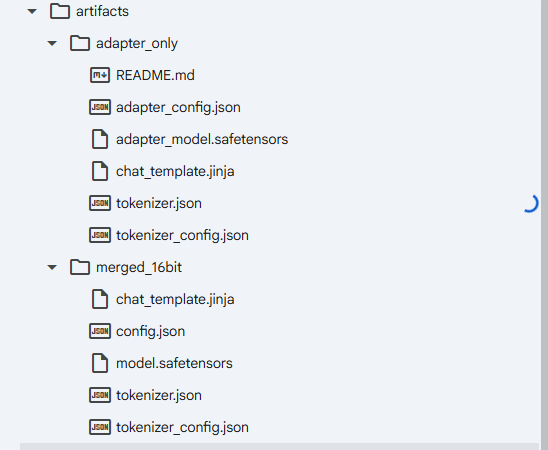

### Запуск со второй версией параметров

In [ ]:
NEED_SECOND_RUN = True

In [ ]:
if NEED_SECOND_RUN:
    conf2 = ablation_confs[0]  # attn-only
    trainer2, _ = run_sft_one(conf2, output_dir="/content/sft_runs/attn_only")

    # quick prompt check
    FastLanguageModel.for_inference(trainer2.model)
    print(generate_chat(trainer2.model, tokenizer, prompts_for_test[2], max_new_tokens=240)[:1500])

    # save adapter
    ADAPTER_DIR_2 = "/content/artifacts/adapter_only_attn"
    os.makedirs(ADAPTER_DIR_2, exist_ok=True)
    trainer2.model.save_pretrained(ADAPTER_DIR_2)
    tokenizer.save_pretrained(ADAPTER_DIR_2)

    # quick lm-eval
    !lm_eval \
      --model hf \
      --model_args pretrained={MODEL_NAME},peft={ADAPTER_DIR_2},trust_remote_code=True \
      --tasks truthfulqa_mc2 \
      --device cuda:0 \
      --batch_size 8 \
      --limit 30 \
      --output_path /content/bench_sft/truthfulqa_attn_only.json

==((====))==  Unsloth 2026.3.4: Fast Qwen3 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
before eos: '<|im_end|>' 151645
before pad: '<|PAD_TOKEN|>' 151669
after eos: '<|im_end|>' 151645
after pad: '<|im_end|>' 151645


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Ablation: {'name': 'attn_only_r8_a16', 'r': 8, 'alpha': 16, 'target': 'attn'}
target_modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj']
trainable params: {'trainable': 2293760, 'total': 390725632, 'trainable_pct': 0.5870513250587052}
Unsloth: Sample packing skipped (custom data collator detected).


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


[VRAM] before train allocated=1908 MB | reserved=1942 MB | max_alloc=1917 MB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,880 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 2,293,760 of 598,343,680 (0.38% trained)


Step,Training Loss,Validation Loss
20,1.711192,1.660155
40,1.510200,1.540144
60,1.601869,1.517903
80,1.472456,1.506733
100,1.400425,1.498119
120,1.470966,1.492687
140,1.460649,1.488870
160,1.441272,1.486454
180,1.436411,1.484543
200,1.449199,1.483767


[VRAM] after train allocated=1901 MB | reserved=1956 MB | max_alloc=4532 MB
train time (min): 20.230497352282207
system
Ты — полезный русскоязычный ассистент.
user
Сформулируй основные каноны архитектуры древних цивилизаций
assistant
Древние цивилизации включают множество культур, которые оказались на различных островах и пусторях планеты. Основными канонами архитектуры древних цивилизаций являются:

1. **Географические и транспортные пути**: Воздушные пути, как умножения орехов, и морские пути, такие как пираты и шпирии, были ключевыми для передачи культур и технологий между различными культурами.

2. **Природные и лесные ресурсы**: Строительство было часто связано с использованием природных материалов, которые были доступны на местах, где они были наиболее распространены.

3. **Культурные связи**: Взаимодействие между разными культурами, как через обмен ресурсами или через социальные связи, способствовало распространению новых технологий и культур.

4. **Экологические факторы**: Важн

In [ ]:
if NEED_SECOND_RUN:
  FastLanguageModel.for_inference(trainer.model)

  for p in prompts_for_test:
      print(p)
      ans = generate_chat(trainer.model, tokenizer, p, max_new_tokens=240)
      print(ans[:1800])
      print('='*250)

Как вкусно приготовить индейку на гриле?
system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
Для того чтобы приготовить индейку на гриле, стоит уделить внимание выбору сырья, подготовке и методу приготовления. Вот пошаговый процесс приготовления:

### Шаги приготовления индейки на гриле

1. **Выбор индейки**
   - Индейка должна быть свежей, умерой и в хорошем состоянии, без мокрых, оставшихся части. Выбирайте индейку с кормовыми или кормовых зернах, так как это более питательно для здоровья.
   - Индейка может быть в бака, в кислом или нежной форме.

2. **Подготовка индейки**
   - Следите за тем, чтобы индейка была полностью выдержана до момента приготовления, чтобы она не была слишком тяжелой. Это помогает ей лучше распределить тепло и питательные вещества.

3. **Подготовка поверхности**
   - Если вы готовите индейку на гриле
Как распознать приближающийся инсульт?
system
Ты — полезный русскоязычный ассистент.
user
Как распознать прибли